#Infomación disponible en:
https://datos.cdmx.gob.mx/dataset/victimas-en-carpetas-de-investigacion-fgj

# Análisis Geoespacial y Temporal de Delitos en CDMX (2020–2023)

**Autor**: Juan Diego Argüello Nájera  
**Herramientas**: Python · pandas · Matplotlib · Seaborn · geopandas · Shapely  
**Dataset**: Fiscalía General de Justicia CDMX (datos abiertos) + Shapefile IECM 2022  
**Fuente**: https://datos.cdmx.gob.mx/dataset/victimas-en-carpetas-de-investigacion-fgj

---

## Objetivo

Analizar la evolución temporal de delitos por alcaldía en la Ciudad de México
entre 2020 y 2023, identificando tendencias, zonas de mayor incidencia y
distribución espacial a nivel colonia en Iztapalapa.

## Preguntas de análisis

1. ¿Cómo ha cambiado la incidencia delictiva por alcaldía entre 2020 y 2023?
2. ¿Qué alcaldías concentran consistentemente más delitos?
3. ¿Cómo se distribuyen los delitos a nivel colonia dentro de Iztapalapa?

## Estructura del notebook

1. Importación de librerías  
2. Función de carga y limpieza anual (`cargar_delitos_anual`)  
3. Integración de datos 2020–2023  
4. Análisis de series de tiempo por alcaldía  
5. Distribución estadística: boxplots e histogramas  
6. Carga del shapefile de colonias CDMX (geopandas)  
7. Georreferenciación de delitos a nivel colonia  
8. Visualización espacial — Iztapalapa  

---
> **Nota sobre los datos**: Los archivos CSV de la FGJ son archivos grandes (>100 MB por año).
> Descárgalos desde el portal de datos abiertos de CDMX y colócalos en la carpeta `/data/`.
> Las instrucciones detalladas están en `/data/instrucciones_descarga.md`.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import itertools
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns

In [ ]:
# Función para cargar y limpiar los datos de un año específico
def cargar_delitos_anual(file_path):
    # Cargar el archivo CSV para el año correspondiente
    df = pd.read_csv(file_path)

    # Eliminar filas sin la columna 'alcaldia_hecho'
    df = df.dropna(subset=['alcaldia_hecho'])
    df = df[~df['alcaldia_hecho'].isin(['NA', 'CDMX (indeterminada)'])]  # Eliminar los valores no deseados

    # Filtrar los delitos de la categoría específica (si aún se desea)
    df = df[df['categoria_delito'] == 'ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA']

    return df

In [ ]:
'''import os
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")

files_by_year = {
    2020: os.path.join(DATA_DIR, "victimasFGJ_2020.csv"),
    2021: os.path.join(DATA_DIR, "victimasFGJ_2021.csv"),
    2022: os.path.join(DATA_DIR, "victimasFGJ_2022.csv"),
    2023: os.path.join(DATA_DIR, "victimasFGJ_2023.csv"),
}
# Crear un diccionario para almacenar los delitos por alcaldía por cada año
delitos_por_alcaldia = {}

# Cargar y contar los delitos por alcaldía para cada año
for year, file_path in files_by_year.items():
    df_delitos = cargar_delitos_anual(file_path)

    # Contamos cuántos delitos ocurrieron en cada alcaldía
    delitos_por_alcaldia[year] = df_delitos['alcaldia_hecho'].value_counts()

# Convertimos el diccionario de delitos por alcaldía en un DataFrame
df_delitos = pd.DataFrame(delitos_por_alcaldia).fillna(0)
'''

In [ ]:
# Leer los archivos CSV para cada año
files_by_year = {
    2020: "/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Delitos CDMX 2019/victimasFGJ_2020.csv",
    2021: "/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Delitos CDMX 2019/victimasFGJ_2021.csv",
    2022: "/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Delitos CDMX 2019/victimasFGJ_2022.csv",
    2023: "/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Delitos CDMX 2019/victimasFGJ_2023.csv"
}

# Crear un diccionario para almacenar los delitos por alcaldía por cada año
delitos_por_alcaldia = {}

# Cargar y contar los delitos por alcaldía para cada año
for year, file_path in files_by_year.items():
    df_delitos = cargar_delitos_anual(file_path)

    # Contamos cuántos delitos ocurrieron en cada alcaldía
    delitos_por_alcaldia[year] = df_delitos['alcaldia_hecho'].value_counts()

# Convertimos el diccionario de delitos por alcaldía en un DataFrame
df_delitos = pd.DataFrame(delitos_por_alcaldia).fillna(0)

<ipython-input-4-a6d8bb0a9dd3>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(alcaldias))  # Utiliza una paleta de colores


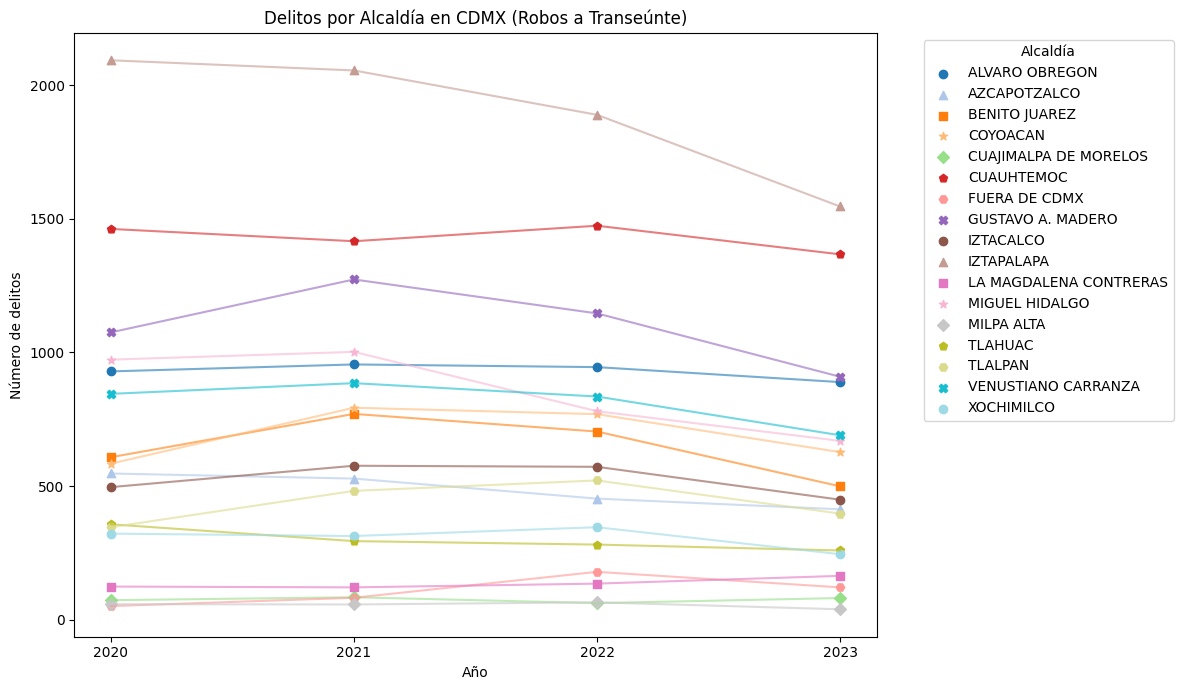

In [ ]:
# Crear el gráfico de dispersión
plt.figure(figsize=(12, 7))

# Asignar un color único a cada alcaldía
alcaldias = df_delitos.index
colors = plt.cm.get_cmap('tab20', len(alcaldias))  # Utiliza una paleta de colores

# Definir los marcadores para diferentes alcaldías (algunos ejemplos: 'o' para círculo, '^' para triángulo, 's' para cuadrado, '*', etc.)
markers = ['o', '^', 's', '*', 'D', 'p', 'H', 'X']  # Lista de diferentes tipos de marcadores
marker_cycle = itertools.cycle(markers)  # Hacer un ciclo con los tipos de marcadores

# Dibujar los puntos y líneas para cada alcaldía
for i, alcaldia in enumerate(alcaldias):
    # Obtener los datos de delitos para esta alcaldía
    delitos_por_anio = df_delitos.loc[alcaldia]

    # Elegir el marcador cíclicamente para cada alcaldía
    marker = next(marker_cycle)

    # Dibujar los puntos con el marcador correspondiente
    plt.scatter([2020, 2021, 2022, 2023], delitos_por_anio, label=alcaldia, color=colors(i), marker=marker)

    # Unir los puntos con una línea
    plt.plot([2020, 2021, 2022, 2023], delitos_por_anio, color=colors(i), alpha=0.6)

# Etiquetas y título del gráfico
plt.xlabel("Año")
plt.ylabel("Número de delitos")
plt.title("Delitos por Alcaldía en CDMX (Robos a Transeúnte)")

# Ajustar el eje X para mostrar solo los años enteros
plt.xticks([2020, 2021, 2022, 2023])

# Leyenda: la leyenda debe mostrar el nombre de la alcaldía junto con su color
# Creamos una leyenda personalizada usando los colores de cada alcaldía
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title="Alcaldía", bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar el gráfico
plt.tight_layout()
plt.show()


#Veamos el contenido del archivo shape

In [ ]:
shapefile_path = os.path.join(DATA_DIR, "colonias_iecm_2022", "colonias_iecm2022_.shp")
colonias = gpd.read_file(shapefile_path)
print(colonias.columns)
print(colonias.head())

In [ ]:
# Leer el shapefile de las colonias
shapefile_path = "/content/drive/MyDrive/Clustering aplicado a Segmentacion de mercado/Delitos CDMX 2019/colonias_iecm_2022/colonias_iecm2022_.shp"
colonias = gpd.read_file(shapefile_path)

# Mostrar las columnas del shapefile
print(colonias.columns)

# Mostrar una vista de las primeras filas para inspeccionar el contenido
print(colonias.head())

Index(['ENTIDAD', 'CDT', 'DEMARCACIO', 'DISTRITOLO', 'DISTRITOL2', 'CVEUT',
       'UT', 'SECCCOMPL', 'SECCPARC', 'POBL', 'geometry'],
      dtype='object')
  ENTIDAD CDT      DEMARCACIO DISTRITOLO DISTRITOL2   CVEUT  \
0       9  10  ALVARO OBREGON         18         18  10-001   
1       9  10  ALVARO OBREGON         18         18  10-002   
2       9  10  ALVARO OBREGON         23         32  10-003   
3       9  10  ALVARO OBREGON         23         23  10-004   
4       9  10  ALVARO OBREGON         23         23  10-005   

                                  UT   SECCCOMPL    SECCPARC  POBL  \
0                   ABRAHAM GONZALEZ        None        3262   459   
1                          ACUEDUCTO        3167  3168, 3169  3188   
2                          ACUILOTLA        None        3391  1927   
3  HACIENDA DE GUADALUPE CHIMALISTAC        None  3460, 3468  1257   
4                 AGUILAS 3ER PARQUE  3508, 3507        None  3832   

                                           

In [ ]:
# Filtrar solo las colonias de la delegación Iztapalapa
colonias_iztapalapa = colonias[colonias['DEMARCACIO'] == 'IZTAPALAPA']

# Crear una lista para almacenar los datos de delitos por año
delitos_anual = {}

#Veamos por colonia

In [ ]:
# Función para cargar y contar los delitos en las colonias de Iztapalapa
def contar_delitos_anual(file_path, colonias_iztapalapa):
    # Cargar los datos del CSV
    df = pd.read_csv(file_path)

    # Eliminar filas sin la columna 'alcaldia_hecho'
    df = df.dropna(subset=['alcaldia_hecho'])
    df = df[~df['alcaldia_hecho'].isin(['NA', 'CDMX (indeterminada)'])]  # Eliminar los valores no deseados

    # Eliminar filas sin latitud ni longitud
    df = df.dropna(subset=['latitud', 'longitud'])

    # Filtrar los delitos de la categoría específica (si aún se desea)
    df = df[df['categoria_delito'] == 'ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA']

    # Crear geometría de los puntos a partir de las columnas 'latitud' y 'longitud'
    geometry = [Point(lon, lat) for lon, lat in zip(df['longitud'], df['latitud'])]

    # Convertir el dataframe original en un GeoDataFrame
    gdf_delitos = gpd.GeoDataFrame(df, geometry=geometry)

    # Asegurarse de que el CRS sea compatible con las colonias
    gdf_delitos.crs = colonias_iztapalapa.crs

    # Realizar la unión espacial entre los delitos y las colonias de Iztapalapa
    delitos_en_colonias = gpd.sjoin(gdf_delitos, colonias_iztapalapa, how="inner", predicate="within")

    # Contamos cuántos delitos hay dentro de cada polígono de colonia
    conteo_delitos_por_colonia = delitos_en_colonias.groupby('UT').size()  # Agrupar por columna 'UT' de las colonias

    # Crear un DataFrame con las colonias de Iztapalapa y asignar 0 delitos por defecto
    conteo_delitos_por_colonia = conteo_delitos_por_colonia.reindex(colonias_iztapalapa['UT'], fill_value=0)

    # Devolver el conteo de delitos por colonia
    return conteo_delitos_por_colonia

In [ ]:
# Inicializar un diccionario vacío para almacenar los datos de delitos por año
delitos_anual = {}

# Contar los delitos para cada año
for anual, file_path in files_by_year.items():
    delitos_anual[anual] = contar_delitos_anual(file_path, colonias_iztapalapa)

# Convertir el diccionario de delitos por año en un DataFrame
# Esto creará un DataFrame con el número de delitos por colonia y por año
df_delitos = pd.DataFrame(delitos_anual)

In [ ]:
df_delitos.head()

,2020,2021,2022,2023
UT,,,,
ACULCO (PBLO),5,5,4,3
ALBARRADAS (U HAB),3,1,1,2
ALCANFORES (U HAB),0,0,0,0
ALLEPETLALI (U HAB),1,2,0,0
ALVARO OBREGON,3,1,3,10


In [ ]:
# Mostrar estadísticas descriptivas
print(df_delitos.describe())

             2020        2021        2022        2023
count  295.000000  295.000000  295.000000  295.000000
mean     7.081356    6.952542    6.389831    5.318644
std      8.445513    8.038880    7.022357    6.454458
min      0.000000    0.000000    0.000000    0.000000
25%      1.000000    1.000000    1.000000    1.000000
50%      4.000000    4.000000    4.000000    3.000000
75%     10.000000   11.000000   10.000000    7.000000
max     52.000000   58.000000   39.000000   37.000000


In [ ]:
# Obtener la suma de los delitos por año
suma_delitos_anual = df_delitos.sum()

# Mostrar la suma de delitos por año
print(suma_delitos_anual)

2020    2089
2021    2051
2022    1885
2023    1569
dtype: int64


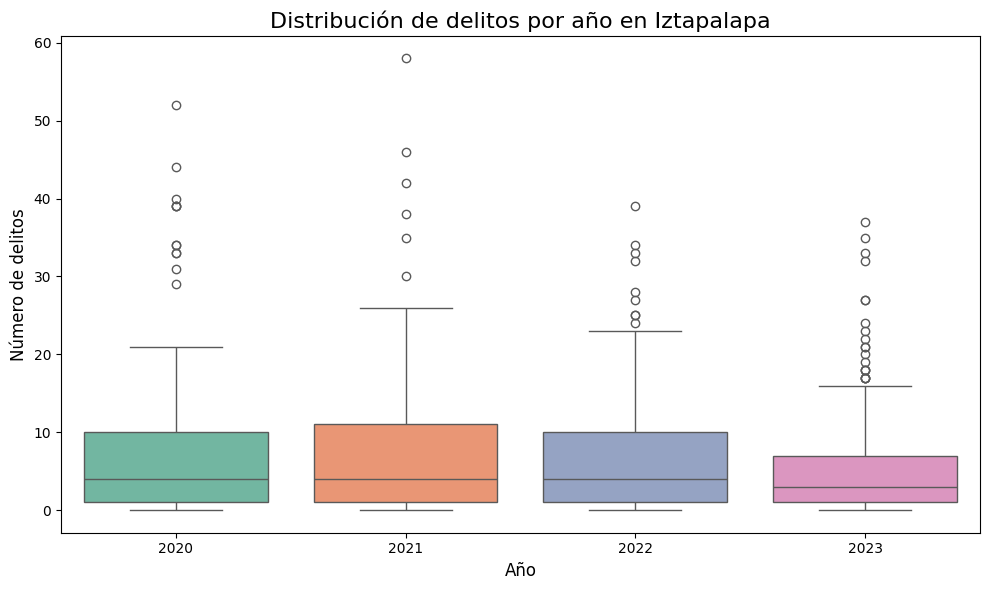

In [ ]:
# Crear un gráfico de cajas para los tres años
plt.figure(figsize=(10, 6))

# Usamos seaborn para dibujar el boxplot
sns.boxplot(data=df_delitos, palette="Set2")

# Agregar títulos y etiquetas
plt.title("Distribución de delitos por año en Iztapalapa", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Número de delitos", fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

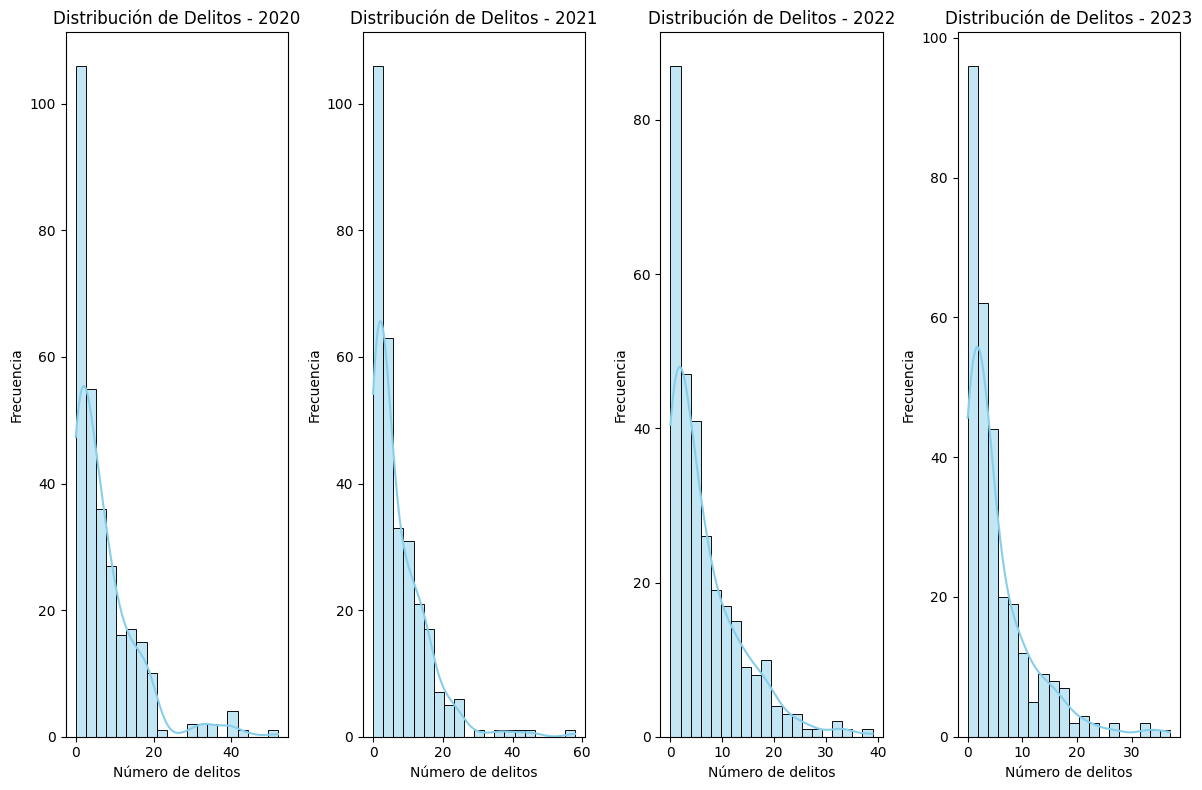

In [ ]:
# Crear un gráfico de histograma para cada año
plt.figure(figsize=(12, 8))

# Dibujar un histograma para cada columna (año) en el DataFrame
for i, año in enumerate(df_delitos.columns):
    plt.subplot(1, len(df_delitos.columns), i + 1)  # Crear un subplot por cada año
    sns.histplot(df_delitos[año], kde=True, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Distribución de Delitos - {año}")
    plt.xlabel('Número de delitos')
    plt.ylabel('Frecuencia')

plt.tight_layout()  # Ajustar el layout para que no se sobrepongan
plt.show()

In [ ]:
# Para cada año, encuentra las colonias con el menor y mayor número de delitos
for año in df_delitos.columns:
    max_delitos = df_delitos[año].max()  # Número máximo de delitos en el año
    min_delitos = df_delitos[año].min()  # Número mínimo de delitos en el año

    # Colonias con el máximo número de delitos
    colonias_max = df_delitos[df_delitos[año] == max_delitos].index.tolist()

    # Colonias con el mínimo número de delitos
    colonias_min = df_delitos[df_delitos[año] == min_delitos].index.tolist()

    # Mostrar los resultados
    print(f"Año {año}:")
    print(f"  Colonias con el mayor número de delitos ({max_delitos} delitos):")
    for colonia in colonias_max:
        print(f"    - {colonia}")

    print(f"  Colonias con el menor número de delitos ({min_delitos} delitos):")
    for colonia in colonias_min:
        print(f"    - {colonia}")
    print("\n")

Año 2020:
  Colonias con el mayor número de delitos (52 delitos):
    - ERMITA ZARAGOZA (U HAB) I
  Colonias con el menor número de delitos (0 delitos):
    - ALCANFORES (U HAB)
    - ANTORCHA POPULAR I (U HAB)
    - BARRANCAS DE GUADALUPE
    - CABEZA DE JUAREZ I (U HAB)
    - CABEZA DE JUAREZ III (U HAB)
    - CACAMA
    - CARMEN SERDAN ( U HAB)
    - CE CUALLI OHTLI (U HAB)
    - CUITLAHUAC (U HAB)
    - EL EDEN
    - EL MANTO_PLAN DE IGUALA
    - EL MOLINO_
    - EL PRADO
    - EL VERGEL TRIANGULO DE LAS AGUJAS I (U HAB)
    - EL VERGEL TRIANGULO DE LAS AGUJAS II (U HAB)
    - ESTADO DE VERACRUZ
    - F P F V (PREDIO EL MOLINO) ( U HAB)
    - GAMA GAVILAN (U HAB)
    - GAVILAN (U HAB)
    - GRANJAS ESTRELLA II
    - GRANJAS ESTRELLA III
    - GUELATAO DE JUAREZ I (U HAB)
    - HUASIPUNGO (U HAB)
    - JUSTO SIERRA
    - LA ESTACION
    - LOMAS EL MANTO
    - LOMAS ESTRELLA  III (U HAB)
    - MINAS POLVORILLA (U HAB) I
    - MONTE ALBAN
    - MOYOCOYANI (U HAB)
    - NA HAL TI (U HA

#Veamos en la UAM-I
La UAM unidad Iztapalapa se encuentra en la colonia Leyes de Reforma 1a sección.

In [ ]:
# Filtrar las colonias que contienen la palabra "LEYES" en su nombre en el shape
colonias_leys = colonias[colonias['UT'].str.contains('LEYES', case=False, na=False)]

# Mostrar los nombres de las colonias que contienen "LEYES"
print(colonias_leys[['UT']])

                                  UT
1092     LEYES DE REFORMA 1A SECCION
1093     LEYES DE REFORMA 2A SECCION
1237   LEYES DE REFORMA 3A SECCION I
1238  LEYES DE REFORMA 3A SECCION II


2020     8
2021    11
2022    16
2023     6
Name: LEYES DE REFORMA 1A SECCION, dtype: int64


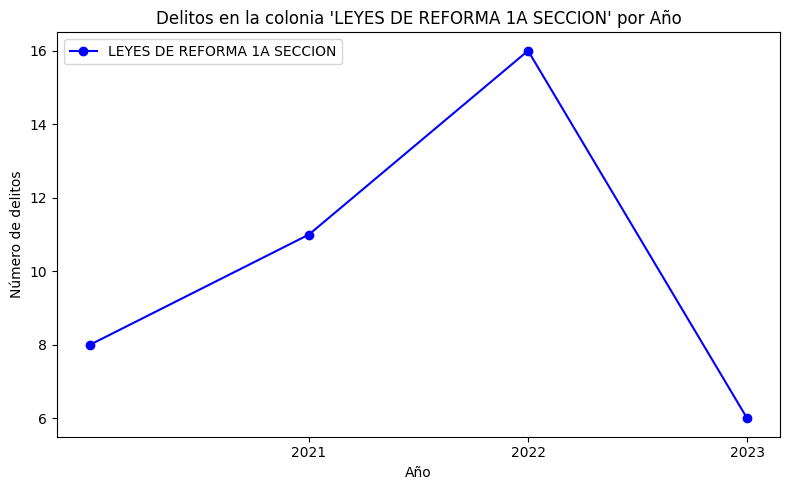

In [ ]:
# Filtrar los datos para la colonia "LEYES DE REFORMA 1A SECCION"
colonia_nombre = "LEYES DE REFORMA 1A SECCION"
delitos_colonia = df_delitos.loc[colonia_nombre]

print(delitos_colonia)
# Crear el gráfico de dispersión
plt.figure(figsize=(8, 5))

# Dibujar los puntos y la línea para la colonia
plt.plot(delitos_colonia.index, delitos_colonia.values, marker='o', color='b', linestyle='-', label=colonia_nombre)

# Etiquetas y título del gráfico
plt.xlabel("Año")
plt.ylabel("Número de delitos")
plt.title(f"Delitos en la colonia '{colonia_nombre}' por Año")

# Ajustar el eje X para que muestre solo los años
plt.xticks([2021, 2022, 2023])

# Agregar leyenda
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#Veamos en el Colegio de Bachilleres Plantel 6
El Colegio de Bachilleres Plantel 6 se encuentra en la colonia Vicente Guerrero Superr Manzana 6.

In [ ]:
# Filtrar las colonias que contienen la palabra "Vicente Guerrero" en su nombre en el shape
colonias_leys = colonias[colonias['UT'].str.contains('VICENTE GUERRERO', case=False, na=False)]

# Mostrar los nombres de las colonias que contienen "VICENTE GUERRERO"
print(colonias_leys[['UT']])

                                            UT
1202  VICENTE GUERRERO SUPER MANZANA 1 (U HAB)
1203  VICENTE GUERRERO SUPER MANZANA 2 (U HAB)
1204  VICENTE GUERRERO SUPER MANZANA 3 (U HAB)
1205  VICENTE GUERRERO SUPER MANZANA 4 (U HAB)
1206  VICENTE GUERRERO SUPER MANZANA 5 (U HAB)
1207  VICENTE GUERRERO SUPER MANZANA 6 (U HAB)
1208  VICENTE GUERRERO SUPER MANZANA 7 (U HAB)


2020    19
2021    11
2022    11
2023    15
Name: VICENTE GUERRERO SUPER MANZANA 6 (U HAB), dtype: int64


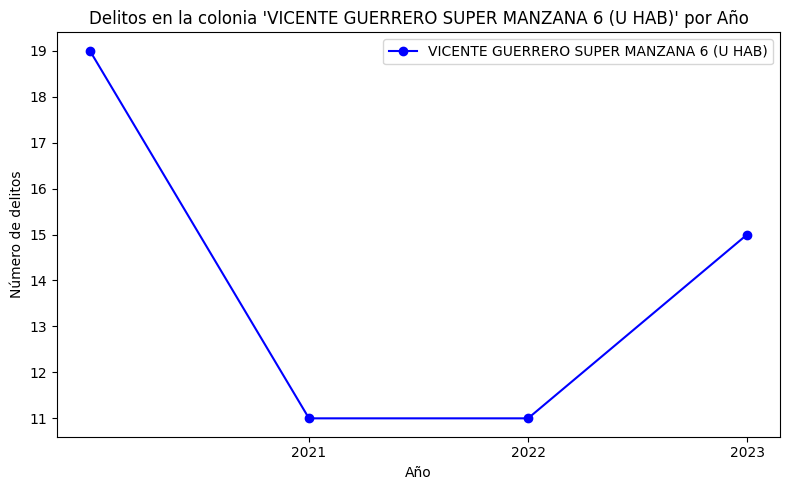

In [ ]:
# Filtrar los datos para la colonia "VICENTE GUERRERO SUPER MANZANA 6 (U HAB)"
colonia_nombre = "VICENTE GUERRERO SUPER MANZANA 6 (U HAB)"
delitos_colonia = df_delitos.loc[colonia_nombre]

print(delitos_colonia)
# Crear el gráfico de dispersión
plt.figure(figsize=(8, 5))

# Dibujar los puntos y la línea para la colonia
plt.plot(delitos_colonia.index, delitos_colonia.values, marker='o', color='b', linestyle='-', label=colonia_nombre)

# Etiquetas y título del gráfico
plt.xlabel("Año")
plt.ylabel("Número de delitos")
plt.title(f"Delitos en la colonia '{colonia_nombre}' por Año")

# Ajustar el eje X para que muestre solo los años
plt.xticks([2021, 2022, 2023])

# Agregar leyenda
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()